In [1]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
%matplotlib inline

In [11]:
EJ = 3
EC = 0.6
EL = 0.13
Er = 7.2622522
g_strength = 0.3

qubit_level = 30
osc_level = 30


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=Er,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
energies=  hilbertspace.eigenvals(qubit_level*osc_level)

products_to_keep = []

for ql in [0]:
    for ol in range(30):
        products_to_keep.append([ql,ol])
for ql in range(1,3):
    for ol in range(10):
        products_to_keep.append([ql,ol])


def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)

def pad_back_function(qobj):
    return pad_back_custom(qobj, products_to_keep, product_to_dressed)

a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)

w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] ) 

tot_time =478
tlist = np.linspace(0, tot_time, tot_time)

amp = 0.004
kappa = 0.005
decay_term = np.sqrt(kappa) * a_trunc

print(w_d)


7.264787679126236


In [12]:
def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi * amp * cos

In [13]:

H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos],
]
results = [None] * 3

# for i in range(3):
#     print(f'doing qubit initial state {i}')
#     results[i] = qutip.mcsolve(psi0=truncate_function(qutip.basis(hilbertspace.dimension, product_to_dressed[(i, 0)])), 
#                                H=H_with_drive,
#                                progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
#                                tlist=tlist, 
#                                c_ops = [decay_term],
#                                e_ops = [a_trunc,a_trunc.dag()*a_trunc],
#                                ntraj = 400,
#                                options=qutip.Options(store_states=False)
#                                )
    


# import pickle
# with open('mcsolve_detection_results.pkl', 'wb') as file:
#     pickle.dump(results, file)

with open('mcsolve_detection_results.pkl', 'rb') as file:
    results = pickle.load(file)

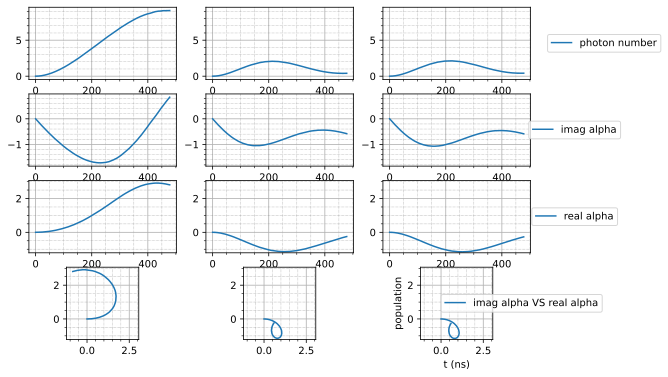

In [27]:

first_dominant_freq =find_dominant_frequency(results[0].expect[0],tlist)
# first_dominant_freq = w_d


nlevels = 3

fig, axes = plt.subplots(4,nlevels, figsize=(9, 6))

for i in range(nlevels):
    alpha = results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)

    # Coherent state eigenval
    real = alpha.real
    imag = alpha.imag
    axes[1][i].plot(tlist,imag , label=r"imag alpha")
    axes[2][i].plot(tlist, real, label=r"real alpha")
    axes[3][i].plot(-imag, real, label=r"imag alpha VS real alpha")
    
    # Photon number
    axes[0][i].plot(tlist, results[i].expect[-1], label=r"photon number")

axes[0][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.5, 0.5))
axes[1][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
axes[2][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
axes[3][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.4, 0.5))
plt.ylabel("population")
plt.xlabel("t (ns)")
for row in [0,1,2,3]:
    max_x_range,min_x_range,max_y_range,min_y_range = 0,0,0,0
    for col in range(nlevels):
        ymin, ymax = axes[row][col].get_ylim()
        xmin, xmax = axes[row][col].get_xlim()
        if ymax > max_y_range:
            max_y_range = ymax
        if ymin < min_y_range:
            min_y_range = ymin
        if xmax > max_x_range:
            max_x_range = xmax
        if xmin < min_x_range:
            min_x_range = xmin
    for col in range(nlevels):
        axes[row][col].set_ylim(min_y_range, max_y_range)
        axes[row][col].set_xlim(min_x_range,max_x_range)
        # Set the third row y range equal x range
        if row == 3:
            axes[row][col].set_ylim(min(min_x_range,min_y_range), max(max_x_range,max_y_range))
            axes[row][col].set_xlim(min(min_x_range,min_y_range),max(max_x_range,max_y_range))
# plt.yscale('log')
for ax in axes.flat:
    ax.minorticks_on()
    ax.grid(True)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
for col in axes[3]:
    col.set_aspect('equal', 'box')
plt.show()



In [30]:
def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     coeff, # in GHz
                     a,w_d,tlist,
                     fourier):

    alphas = []
    for i in [res_idx1,res_idx2]:
        alphas.append(results[i].expect[0])

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*coeff*squared_diff[i]
                         )
    # Step-3 Plot
    plt.figure()
    plt.plot(tlist, integrals, label='Integral')
    plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    plt.show()
    return integrals


# From the photon counting statistics paper, the coefficient should be kappa squared. I plotted contrast of both kappa and kappa squared.

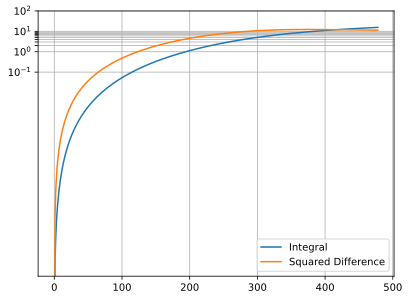

In [31]:
integrals = compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                coeff = kappa,
                a = a,w_d = w_d,tlist = results[0].times,
                fourier = True)

import pickle
with open('mcsolve_integral_kappa5e-3.pkl', 'wb') as file:
    pickle.dump(integrals, file)

# On reference states:

In [14]:
state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]

ntraj = 400

tomo_results = [None] * 4
    
for i in range(4):
    print(f'doing qubit initial state {i}')
    tomo_results[i] = qutip.mcsolve(psi0=truncate_function(initial_states[i]), 
                               H=H_with_drive,
                               progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
                               tlist=tlist, 
                               c_ops = [decay_term],
                               e_ops = [a_trunc,a_trunc.dag()*a_trunc],
                               ntraj = ntraj,
                               options=qutip.Options(store_states=True)
                               )

import pickle
with open('mcsolve_tomo_results_kappa5e-3.pkl', 'wb') as file:
    pickle.dump(tomo_results, file)

# with open('mcsolve_tomo_results_kappa5e-3.pkl', 'rb') as file:
#     tomo_results = pickle.load(file)

doing qubit initial state 0
 Total run time: 1822.56s] Elapsed 1822.54s / Remaining 00:00:00:00
doing qubit initial state 1
 Total run time: 1765.43s] Elapsed 1765.41s / Remaining 00:00:00:00
doing qubit initial state 2
 Total run time: 1698.84s] Elapsed 1698.83s / Remaining 00:00:00:00
doing qubit initial state 3
 Total run time: 1728.54s] Elapsed 1728.53s / Remaining 00:00:00:00


# result.states is a 2-d array of shape (n_traj, len(tlist)), each element is a ket,

## we first do averaging over the ntraj kets

In [15]:
dm_tomo_results_list = []
for result in tomo_results:
    new_result = qutip.solver.Result()
    new_result.times = result.times

    states_array = np.array([[state.full() for state in traj] for traj in result.states])
    summed_dm_array = np.einsum('ntrc,ntij->tri', states_array, states_array.conj()) # n is traj index, t is time index, r is row index, c is column index, i and j are the row and column index of the conjugated ket
    averaged_dm_array = summed_dm_array/ntraj
    new_result.states = [qutip.Qobj(dm) for dm in averaged_dm_array]

    dm_tomo_results_list.append(new_result)


# because we need to do partial trace to get qubit dm, we have to convert the truncated dressed dm into a product dm

In [16]:
import shutil
dir_name = 'temp_tomo'
if os.path.exists(dir_name):
    shutil.rmtree(dir_name)
os.mkdir(dir_name)
tasks = [(dm_tomo_results_list, 
          f'{dir_name}/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2,products_to_keep) 
         for i in range(len(dm_tomo_results_list)) 
         for j in range(len(dm_tomo_results_list[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

In [17]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero +  one).unit(),
              (zero - one).unit() ]


num_initial_states = len(dm_tomo_results_list)
num_time_steps = len(dm_tomo_results_list[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'{dir_name}/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

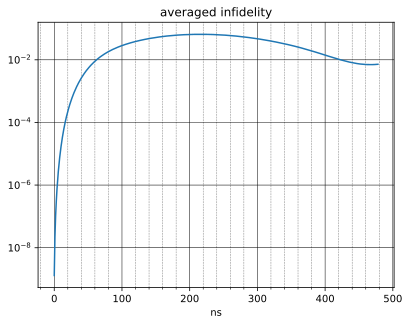

In [18]:
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(dm_tomo_results_list[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

In [19]:
import pickle
with open('mcsolve_infidelity_kappa5e-3.pkl', 'wb') as file:
    pickle.dump(infidelity, file)

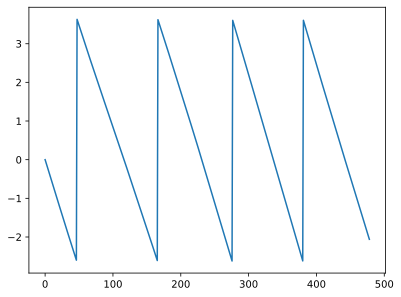

In [20]:
plt.plot(dm_tomo_results_list[0].times,phase,label = f'phase')

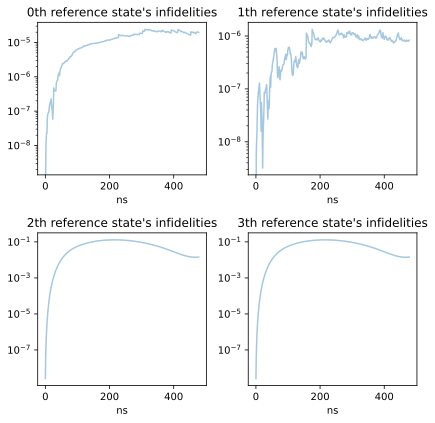

In [21]:
def calc_fidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    return 1-qutip.fidelity(dm, gate*state_ideal)

    

phases = []
infidelities = []
for i, states in enumerate(two_level_states):
    phases.append([])
    infidelities.append([])
    for idx in range(num_time_steps):
        dm = states[idx]
        def objective_function(params):
            return calc_fidelity_with_phase(params[0], dm, states_ideal[i])
        initial_phase = [0.0]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        phases[-1].append(opt_result.x)
        infidelities[-1].append(opt_result.fun)

fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()
for i in range(4):
    axs[i].plot(dm_tomo_results_list[0].times, infidelities[i], label=f'{i}th infidelities', alpha=0.4)
    axs[i].set_title(f"{i}th reference state's infidelities")
    axs[i].set_xlabel("ns")
    axs[i].set_yscale('log')
    # axs[i].legend()

plt.tight_layout()
plt.show()